# Training of a KIND-based reinforcement learning policy (KIND-RL)

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import cm
from tabulate import tabulate

from scipy.linalg import block_diag
from collections import deque

import kind
import duffing
import util_data
import util_nn
import reinforcement_learning

## Recreate a Duffing environment

In [2]:
# --! define Duffing parameters --!

# --! define parameters of a nominal Duffing which is supposed to be stabilized by an LQR
duffing_alpha_nom = -1.0
duffing_delta_nom = 0.5

# --! define parameters of an anomalous Duffing which exhibits excursions from one well to the other
duffing_alpha = -110.0
duffing_beta = 140.0
duffing_gamma = 70.0
duffing_delta = duffing_delta_nom

In [3]:
# --! make a base policy --!

state_ndim = 2
action_ndim = 1

state_cost = 1.0 * np.eye(state_ndim)
action_cost = 10.0 * np.eye(action_ndim)

# --! we aim to capture the Duffing in well (1,0)
setpoint = [1.0, 0.0]
dt = 1e-2

base_policy, p = duffing.make_base_policy(
    duffing_alpha_nom, duffing_delta_nom,
    q=state_cost, r=action_cost,
    dt=dt,
    setpoint=setpoint)


In [4]:
# --! define a Duffing reward function --!

reward_fn = duffing.reward(state_cost, action_cost, setpoint)

In [5]:
# --! make a Duffing oscillator --!

env = duffing.environment(
    reward_fn,
    alpha=duffing_alpha, beta=duffing_beta, gamma=duffing_gamma, delta=duffing_delta,
    dt_control=dt)

env = duffing.environment_adapter(env)

## Load a trained KIND model

In [6]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

model_args = parser.parse_args(
    args=[
        '--file_dir', '../../data/duffing',
        '--file_name', 'duffing',
        '--data_nsample_nom', '253',
        '--data_nsample_exc', '460',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.9',

        '--back_nsample', '64',
        '--fore_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/duffing',

        '--rez_nsample_nom', '32',
        '--rez_nsample_exc', '16',
        '--embed_nom', '{"sin": 6, "cos": 6}',
        '--embed_exc', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

# --! instantiate a KIND model
model = kind.model(model_args)

# --! load trained weights into the model
model_path = model_args.checkpoints + '/' + '20260303_checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))

dataset = duffing.dataset(
    model_args.file_dir, model_args.file_name, model_args.file_index, model_args.file_ext,
    model_args.data_nsample_nom, model_args.data_nsample_exc,
    (model_args.data_train_size, model_args.data_test_size),
    model_args.batch_size, (model_args.back_nsample, model_args.fore_nsample), setpoint, load_normalized=False)

model = kind.model_adapter(model, dataset.normalizer)

## Make a replay with the Duffing environment

In [7]:
obs_nsample = model_args.back_nsample
skip_nsample = 10 * obs_nsample
env_ic = torch.zeros(1,1,2)
residual_policy = None

replay = env.replay(env_ic, reinforcement_learning.policies(base_policy, residual_policy), obs_nsample, skip_nsample)

## Policy iteration: instantiate method

In [8]:
# --! specify kind arguments --!

parser = reinforcement_learning.create_args_parser()

policy_args = parser.parse_args(
    args=[
        '--gamma', '0.995',
        '--rollout_nsample', '2',
        '--back_reset_nsample', '20',
    ]
)

pi = reinforcement_learning.policy_iteration(policy_args)

In [9]:
# --! instantiate value function and residual policy --!

value_fn = reinforcement_learning.value_fn(dataset.normalizer)
residual_policy = reinforcement_learning.policy(dataset.normalizer, gain=0.5)

## Policy iteration: train a value function

In [10]:
# --! 1. step in policy iteration: policy evaluation --!

loss = pi.evaluate_policy(value_fn, replay)

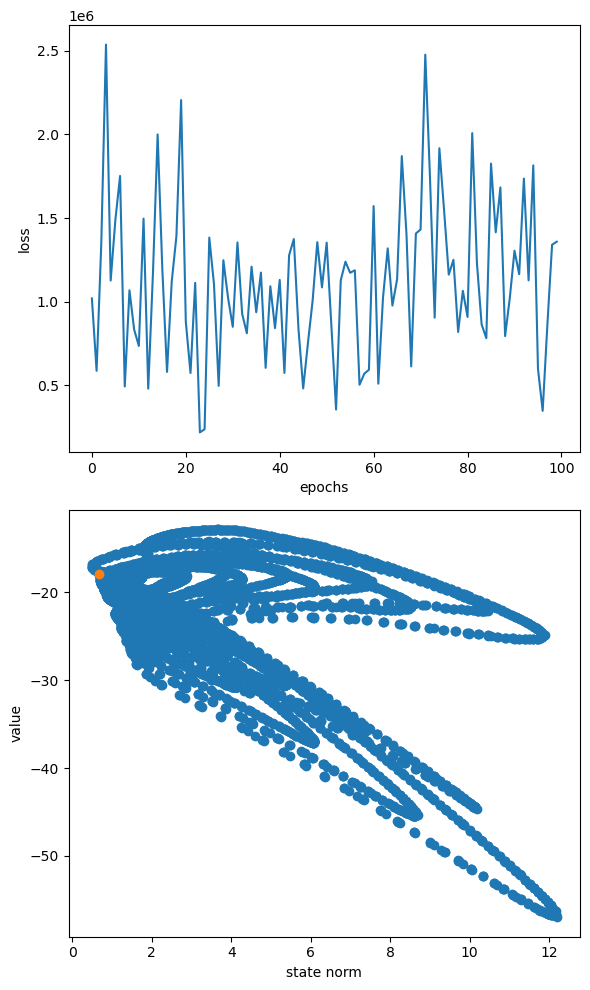

In [11]:
# --! plot value function training information --!

value_fn.eval()

obs, reward, next_obs, done = replay.to_data()
s = replay.util.get_s(obs)
s_norm = torch.squeeze(torch.linalg.norm(s, dim=-1, ord=2))
value = torch.squeeze(value_fn(s))

with torch.no_grad():

    plt.figure(figsize=(6,10))

    plt.subplot(2,1,1)
    plt.plot(loss)
    plt.xlabel('epochs')
    plt.ylabel('loss')

    plt.subplot(2,1,2)
    plt.scatter(s_norm, value)
    plt.scatter(s_norm[0], value[0])
    plt.xlabel('state norm')
    plt.ylabel('value')

    plt.tight_layout()
    plt.show()


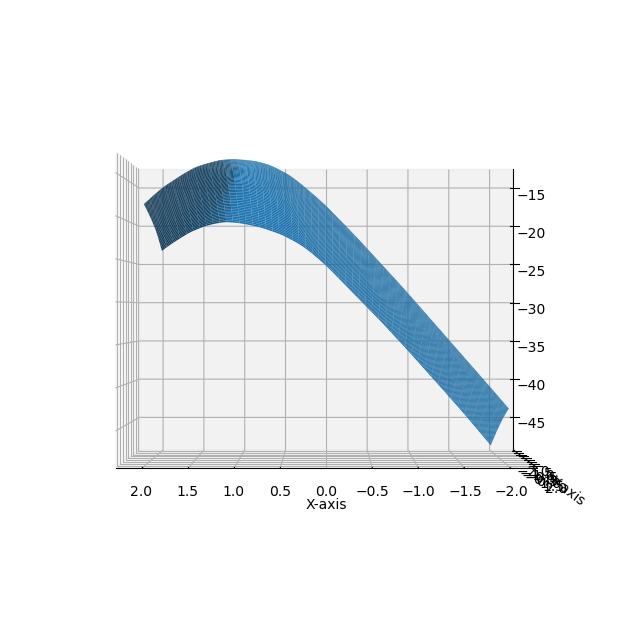

In [12]:
# --! check value function shape --!

x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-2, 2, 200)
X1, X2 = np.meshgrid(x1, x2)

grid = np.stack([X1.ravel(), X2.ravel()], axis=1)

# subtract setpoint
grid_err = grid - np.array([1.0, 0.0])

# convert to torch tensor
grid_err = torch.tensor(grid_err, dtype=torch.float32)
grid_err = torch.unsqueeze(grid_err, 0)

with torch.no_grad():
    V = torch.squeeze(value_fn(grid_err))
    V = V.cpu().numpy()

V = V.reshape(X1.shape)

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, V)
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.view_init(0, 90)


## Policy iteration: train a reinforcement learning policy

In [13]:
# --! 2. step in policy iteration: policy improvement --!

# --! train a policy
loss = pi.improve_policy(model, reinforcement_learning.policies(base_policy, residual_policy), value_fn, env, replay)

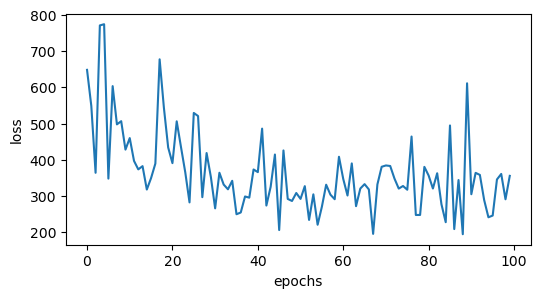

In [14]:
# --! plot policy improvement loss --!

with torch.no_grad():

    plt.figure(figsize=(6,3))

    plt.plot(loss)
    plt.xlabel('epochs')
    plt.ylabel('loss')

    plt.show()


## Collecting Duffing replay data with a trained residual (RL) policy

Now the baseline stabilizing LQR policy is augmented with a trained reinforcement learning policy.

In [15]:
# --! run Duffing replay with trained RL policy --!

residual_policy.eval()

with torch.no_grad():
    replay2 = env.replay(env_ic, reinforcement_learning.policies(base_policy, residual_policy), obs_nsample, skip_nsample)


## Evaluating results

In [16]:
# --! collect advantage data --!

value_fn.eval()
residual_policy.eval()

with torch.no_grad():
    adv = pi.compute_advantage(
        model,
        reinforcement_learning.policies(base_policy, residual_policy),
        value_fn,
        env, replay2
    )


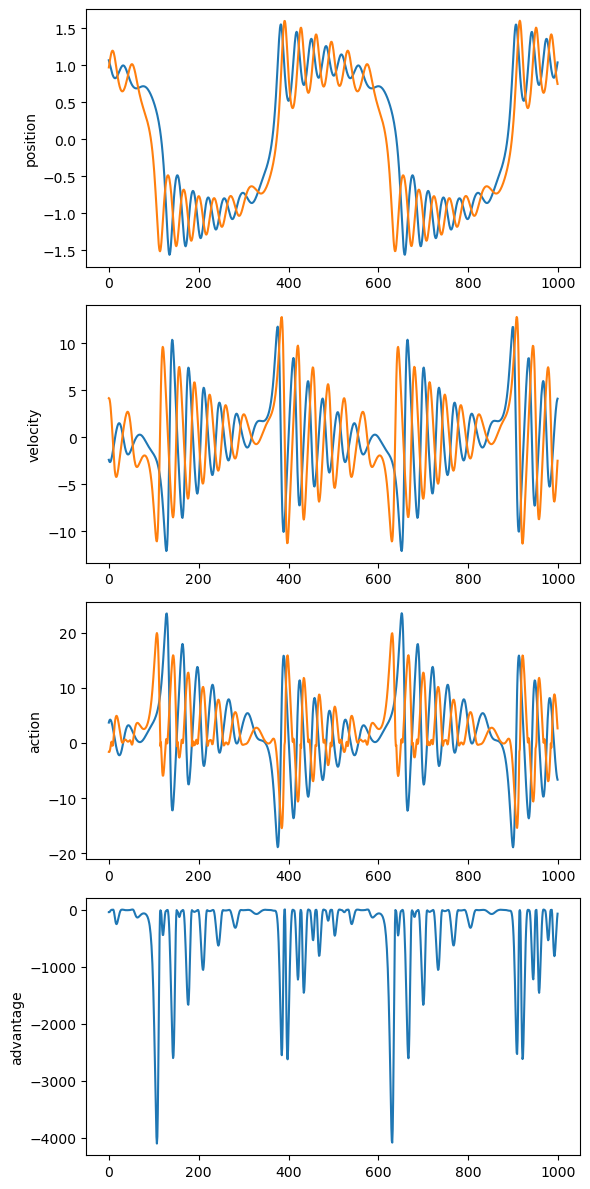

In [17]:
# --! plot comparisons between LQR-only and hybrid policy scenarios --!

lookback, reward, next_lookback, done = replay.to_data()
state1 = replay.util.get_s(lookback)
action1 = replay.util.get_a(lookback)

lookback, reward, next_lookback, done = replay2.to_data()
state2 = replay2.util.get_s(lookback)
action2 = replay2.util.get_a(lookback)

with torch.no_grad():

    plt.figure(figsize=(6,12))

    plt.subplot(4,1,1)
    plt.plot(state1[-1000:, 0, 0])
    plt.plot(state2[-1000:, 0, 0])
    plt.ylabel('position')

    plt.subplot(4,1,2)
    plt.plot(state1[-1000:, 0, 1])
    plt.plot(state2[-1000:, 0, 1])
    plt.ylabel('velocity')

    plt.subplot(4,1,3)
    plt.plot(action1[-1000:, 0, :])
    plt.plot(action2[-1000:, 0, :])
    plt.ylabel('action')

    plt.subplot(4,1,4)
    plt.plot(adv[-1000:, 0, 0])
    plt.ylabel('advantage')

    plt.tight_layout()
    plt.show()

    datasaved = False

    if datasaved:
        step = torch.arange(1000).reshape(1, -1, 1)
        step = step

        state11 = state1[-1000:, :1, :1].reshape(1, -1, 1)
        state12 = state1[-1000:, :1, 1:2].reshape(1, -1, 1)
        action11 = action1[-1000:, :1, :1].reshape(1, -1, 1)

        state21 = state2[-1000:, :1, :1].reshape(1, -1, 1)
        state22 = state2[-1000:, :1, 1:2].reshape(1, -1, 1)
        action21 = action2[-1000:, :1, :1].reshape(1, -1, 1)
        adv21 = adv[-1000:, :1, :1].reshape(1, -1, 1)
        adv21 = adv21 / 1e4

        savedata = np.concatenate([
            step,
            state11, state12, action11], axis=2)
        util_data.write_datafile(f'../../results/duffing/duffing_kindrl_baseline', savedata, delim=' ')

        savedata = np.concatenate([
            step,
            state21, state22, action21, adv21], axis=2)
        util_data.write_datafile(f'../../results/duffing/duffing_kindrl_h2_gamma0995_umax05', savedata, delim=' ')


In [18]:
# --! compute cost, dwell time, effort to compare different scenarios --!

def cumulative_cost(states, actions, q, r):

    total = 0.0
    for x, u in zip(states, actions):
        x = x.reshape(-1, 1)
        u = u.reshape(-1, 1)

        state_cost = x.T @ q @ x
        action_cost = u.T @ r @ u

        total += state_cost.item() + action_cost.item()
    
    return total

def residence_time_energy(states, alpha, beta):
    total = 0
    for x in states:
        q, qdot = x
        energy = 0.5*qdot**2 + 0.5*alpha*q**2 + 0.25*beta*q**4
        if q > 0 and energy < 0:
            total += 1
    return total

def rms_control(actions):
    return np.sqrt(np.mean(actions**2))

s1 = state1.reshape(-1, 2).numpy()
s2 = state2.reshape(-1, 2).numpy()
a1 = action1.reshape(-1, 1).numpy()
a2 = action2.reshape(-1, 1).numpy()

cost1 = cumulative_cost(s1, a1, state_cost, action_cost)
cost2 = cumulative_cost(s2, a2, state_cost, action_cost)

steps1 = residence_time_energy(s1, duffing_alpha, duffing_beta)
steps2 = residence_time_energy(s2, duffing_alpha, duffing_beta)

effort1 = rms_control(a1)
effort2 = rms_control(a2)

print(
    tabulate(
        [
            ['LQR', cost1/1e6, steps1, effort1],
            [f'KIND-RL | H={policy_args.rollout_nsample}', cost2/1e6, steps2, effort2]
        ],
        headers=['Policy', 'Cost', 'Dwell', 'Effort']))


Policy            Cost    Dwell    Effort
-------------  -------  -------  --------
LQR            5.01013     3477   7.21582
KIND-RL | H=2  3.48254     2660   5.93805
